In [1]:
pip install contextily

In [2]:
pip install adjustText

Note: you may need to restart the kernel to use updated packages.


In [3]:
import warnings
import pandas as pd
import numpy as np
import zipfile
import requests
from sklearn.cluster import KMeans
import geopandas as gpd
from shapely.geometry import Point
import networkx as nx
warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)
import os

In [4]:
##change here
base_path = r"C:\Users\AvaGROSSMAN\Desktop\bridging-nyc"

# Data Cleaning

## Read Opportunity Atlas Data

In [5]:
##this dataset is filtered to nyc already for processing purposes
oa = pd.read_csv(os.path.join(base_path,"data_raw","oa_nyc_filtered.csv"))

In [6]:
oa.head()

,Unnamed: 0,geoid10,score10,se10
0,42961,36005000200,0.420510,0.017681
1,42962,36005000400,0.405993,0.020622
2,42963,36005001600,0.408697,0.012577
3,42964,36005001900,0.337812,0.020684
4,42965,36005002000,0.344373,0.008737


## Read Neighborhood Tabulation Translation 

In [7]:
#translates 2010 tracts to 2020 tracts
cw = pd.read_excel(os.path.join(base_path,"data_raw","CENSUS_TRACT_CROSSWALK_2010_to_2020_2010.xlsx"),
    dtype={"GEOID_2010": str, "GEOID_2020": str}
)

In [8]:
cw.head()

,GEOID_2010,GEOID_2020,RES_RATIO,BUS_RATIO,OTH_RATIO,TOT_RATIO
0,01001020100,01001020100,1.000000,1.000000,1.000000,1.000000
1,01001020200,01001020100,0.001225,0.086777,0.085714,0.022873
2,01001020200,01001020200,0.998775,0.913223,0.914286,0.977127
3,01001020300,01001020300,1.000000,1.000000,1.000000,1.000000
4,01001020400,01001020400,1.000000,1.000000,1.000000,1.000000


In [9]:
#translates tracts to neighborhoods
eq = pd.read_csv(os.path.join(base_path,"data_raw","2020_Census_Tracts_to_2020_NTAs_and_CDTAs_Equivalency.csv"))

In [10]:
eq.head()

,GEOID,CountyFIPS,BoroCode,BoroName,BoroCT2020,CT2020,CTLabel,NTACode,NTAType,NTAName,NTAAbbrev,CDTACode,CDTAType,CDTAName
0,36005001901,5,2,Bronx,2001901,1901,19.01,BX0101,0,Mott Haven-Port Morris,MttHvn,BX01,CD,BX01 Melrose-Mott Haven-Port Morris (CD 1 Appr...
1,36005001902,5,2,Bronx,2001902,1902,19.02,BX0101,0,Mott Haven-Port Morris,MttHvn,BX01,CD,BX01 Melrose-Mott Haven-Port Morris (CD 1 Appr...
2,36005001903,5,2,Bronx,2001903,1903,19.03,BX0101,0,Mott Haven-Port Morris,MttHvn,BX01,CD,BX01 Melrose-Mott Haven-Port Morris (CD 1 Appr...
3,36005002300,5,2,Bronx,2002300,2300,23.00,BX0101,0,Mott Haven-Port Morris,MttHvn,BX01,CD,BX01 Melrose-Mott Haven-Port Morris (CD 1 Appr...
4,36005002500,5,2,Bronx,2002500,2500,25.00,BX0101,0,Mott Haven-Port Morris,MttHvn,BX01,CD,BX01 Melrose-Mott Haven-Port Morris (CD 1 Appr...


## Filter Opportunity Atlas data to NYC

## Select mobility score

In [11]:
oa_filt = oa.copy()
# score10 = kfr_pooled_pooled_p25 from opportunity atlas. se10 is the standard error
oa_filt = oa_filt[["geoid10", "score10","se10"]].dropna(subset=["score10","se10"])
oa_filt.head()

,geoid10,score10,se10
0,36005000200,0.420510,0.017681
1,36005000400,0.405993,0.020622
2,36005001600,0.408697,0.012577
3,36005001900,0.337812,0.020684
4,36005002000,0.344373,0.008737


### Sanity checks

In [12]:
oa_use = oa_filt.copy()

In [13]:
oa_use["geoid10"].is_unique == True

True

In [14]:
# 1
print("Unique GEOID_2010 in opportunity atlas:",oa_use['geoid10'].nunique(),"Rows:", len(oa_use))
# 2
print("Duplicates in opportunity atlas:",oa_use.duplicated("geoid10").sum())

Unique GEOID_2010 in opportunity atlas: 2097 Rows: 2097
Duplicates in opportunity atlas: 0


In [15]:
oa_use["geoid10"] = oa_use["geoid10"].astype(str).str.strip()
oa_use["geoid10"] = oa_use["geoid10"].str.zfill(11)
oa_use["score10"].describe()

count    2097.000000
mean        0.452301
std         0.083220
min         0.038465
25%         0.384867
50%         0.441168
75%         0.517830
max         0.755677
Name: score10, dtype: float64

## Merge Opportunity Atlas mobility score and GEOID (from 2010) to the crosswalk table

### Sanity checks

In [16]:
cw.groupby("GEOID_2010")["RES_RATIO"].sum().describe()

count    72576.000000
mean         0.995398
std          0.067683
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: RES_RATIO, dtype: float64

In [17]:
# 1
print("Unique GEOID_2010 in crosswalk:",cw["GEOID_2010"].nunique(),"Rows:", len(cw))

# 2
print("Duplicates in crosswalk:",cw.duplicated("GEOID_2010").sum())

Unique GEOID_2010 in crosswalk: 72576 Rows: 97476
Duplicates in crosswalk: 24900


In [18]:
cw.groupby(["GEOID_2010","GEOID_2020"]).size().describe()

count    97476.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
dtype: float64

In [19]:
cw.groupby(["GEOID_2010","GEOID_2020"]).size().max() == 1

True

In [20]:
cw_check = (
    cw
    .groupby(["GEOID_2010","GEOID_2020"], as_index=False)
    .agg(TOT_RES_RATIO=("RES_RATIO","sum"))
)
cw_check.groupby("GEOID_2010")["TOT_RES_RATIO"].sum().describe()

count    72576.000000
mean         0.995398
std          0.067683
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: TOT_RES_RATIO, dtype: float64

In [21]:
oa_use["geoid10"]=oa_use["geoid10"].astype(str).str.strip()
oa_use["geoid10"]=oa_use["geoid10"].str.zfill(11)
cw["GEOID_2020"] = cw["GEOID_2020"].astype(str).str.strip()
cw["GEOID_2010"] = cw["GEOID_2010"].astype(str).str.strip()
cw["GEOID_2020"] = cw["GEOID_2020"].str.zfill(11)
cw["GEOID_2010"] = cw["GEOID_2010"].str.zfill(11)

In [22]:
m = cw.merge(oa_use, left_on="GEOID_2010", right_on = "geoid10" , how="left")
m["score10"].describe()

count    2257.000000
mean        0.451482
std         0.082740
min         0.038465
25%         0.384620
50%         0.441168
75%         0.515613
max         0.755677
Name: score10, dtype: float64

In [23]:
# Checks
print(len(m))
print("Duplicates after merge:",m.duplicated(["GEOID_2010","GEOID_2020"]).sum())
print("Missing scores: ", len(m[m["score10"].isna()]["score10"]))

97476
Duplicates after merge: 0
Missing scores:  95219


## Compute a 2020 tract score (weighted average of contributing 2010 tracts):

In [24]:
# Compute numerator and denominator per GEOID_2020
m["w_score"] = m["RES_RATIO"] * m["score10"]

out = (
    m.groupby("GEOID_2020", as_index=False)
     .agg(numerator=("w_score", "sum"),
          denom=("RES_RATIO", "sum"))
)

# Final weighted average
out["score20"] = out["numerator"] / out["denom"]
tract20 = out.copy()
tract20

,GEOID_2020,numerator,denom,score20
0,01001020100,0.0,1.001225,0.0
1,01001020200,0.0,0.998775,0.0
2,01001020300,0.0,1.000000,0.0
3,01001020400,0.0,1.000000,0.0
4,01001020501,0.0,0.364692,0.0
...,...,...,...,...
83870,56043000200,0.0,1.000000,0.0
83871,56043000301,0.0,1.000000,0.0
83872,56043000302,0.0,1.000000,0.0
83873,56045951100,0.0,0.985325,0.0


## Retrieve the 2020 populations  for population-weighted scores

In [25]:
def pl2020_tract_pop(state_fips, county_fips):
    url = (
        "https://api.census.gov/data/2020/dec/pl"
        f"?get=P1_001N&for=tract:*&in=state:{state_fips}%20county:{county_fips}"
    )
    r = requests.get(url)
    r.raise_for_status()
    j = r.json()
    df = pd.DataFrame(j[1:], columns=j[0])
    df["GEOID_2020"] = df["state"] + df["county"] + df["tract"]
    df["pop20"] = pd.to_numeric(df["P1_001N"], errors="coerce").astype("Int64")
    return df[["GEOID_2020","pop20"]]


nyc_pops = pd.concat(
    [pl2020_tract_pop("36", c) for c in ["005","047","061","081","085"]],
    ignore_index=True
)

nyc_pops.shape, nyc_pops["GEOID_2020"].nunique()

((2327, 2), 2327)

In [26]:
nyc_pops.head()

,GEOID_2020,pop20
0,36005000100,3772
1,36005000200,4779
2,36005000400,6272
3,36005001600,5795
4,36005001901,2292


In [27]:
nyc_pops["GEOID_2020"] = nyc_pops["GEOID_2020"].astype(str).str.strip()
nyc_pops["GEOID_2020"] = nyc_pops["GEOID_2020"].str.zfill(11)

In [28]:
tract20_pop = tract20.merge(nyc_pops, on="GEOID_2020", how="left")
tract20_pop

,GEOID_2020,numerator,denom,score20,pop20
0,01001020100,0.0,1.001225,0.0,<NA>
1,01001020200,0.0,0.998775,0.0,<NA>
2,01001020300,0.0,1.000000,0.0,<NA>
3,01001020400,0.0,1.000000,0.0,<NA>
4,01001020501,0.0,0.364692,0.0,<NA>
...,...,...,...,...,...
83870,56043000200,0.0,1.000000,0.0,<NA>
83871,56043000301,0.0,1.000000,0.0,<NA>
83872,56043000302,0.0,1.000000,0.0,<NA>
83873,56045951100,0.0,0.985325,0.0,<NA>


In [29]:
missing = tract20_pop.loc[tract20_pop["pop20"].isna(), "GEOID_2020"].drop_duplicates()
#empty list means NYC is captured
print([x for x in list(tract20_pop["pop20"]) if str(x)[:1] =="36"]) 

[]


In [30]:
tract20_pop = tract20_pop.dropna(subset=["pop20"])
tract20_pop["score20"].describe()

count    2270.000000
mean        0.444427
std         0.099347
min         0.000000
25%         0.381318
50%         0.438647
75%         0.514575
max         0.755677
Name: score20, dtype: float64

## Going from 2020 tract to 2020 NTA equivalency

In [31]:
eq["GEOID"] = eq["GEOID"].astype(str).str.strip()
eq["GEOID"] = eq["GEOID"].str.zfill(11)

In [32]:
# join 2020 tracts to 2020 NTAs
nbhd = tract20_pop.merge(eq[["GEOID", "NTACode","NTAName","NTAType","BoroName"]],
                  left_on="GEOID_2020", right_on="GEOID", how="left")

In [33]:
# How many distinct neighborhoods does each tract map to?
# check if any tracts appears with multiple neighborhoods
cnt = (nbhd.groupby("GEOID_2020")["NTACode"]
               .nunique()
               .sort_values(ascending=False))

print("Max neighborhoods per tract:", cnt.max())
print("Tracts mapping to >1 neighborhood:", (cnt > 1).sum())

# list examples
print(cnt[cnt > 1].head(20))

Max neighborhoods per tract: 1
Tracts mapping to >1 neighborhood: 0
Series([], Name: NTACode, dtype: int64)


## Calculate population weighted scores by neighborhood

In [34]:
#0: Residential (Standard residential neighborhood tabulation area)
#5: Rikers Island
#6: Other Special Areas (Includes locations like forts, navy yards, etc.)
#7: Cemetery
#8: Airport
#9: Park (Large parks) 
#filter to residential type only
nbhd=nbhd[nbhd["NTAType"]==0]

In [35]:
#remove any neighborhoods with 0 population
nbhd_scores = nbhd.dropna(subset=["NTACode", "score20", "pop20"])
nbhd_scores = nbhd_scores[nbhd_scores["pop20"] > 0]

In [36]:
# Compute numerator and denominator per NTA
nbhd_scores["pop_score"] = nbhd_scores["pop20"] * nbhd_scores["score20"]

nbhd_scores_w = (nbhd_scores.groupby("NTACode", as_index=False)
           .agg(numer=("pop_score", "sum"),
                denom=("pop20", "sum")))

# Final weighted average
nbhd_scores_w["score_w"] = nbhd_scores_w["numer"] / nbhd_scores_w["denom"]
nbhd_scores_w

,NTACode,numer,denom,score_w
0,BK0101,19169.66156,38980,0.491782
1,BK0102,22025.674072,53908,0.408579
2,BK0103,14029.013368,37731,0.371817
3,BK0104,23310.670014,52998,0.439841
4,BK0201,11394.774831,25092,0.45412
...,...,...,...,...
192,SI0301,11839.126072,22388,0.528816
193,SI0302,30279.647214,54699,0.553569
194,SI0303,17533.89567,30683,0.571453
195,SI0304,23408.864289,40534,0.577512


In [37]:
nbhd_scores_w["score_w"].describe()

count       197.0
mean     0.450615
std      0.071854
min      0.326442
25%      0.386184
50%      0.440427
75%      0.513888
max      0.602811
Name: score_w, dtype: Float64

In [38]:
nyc_scores = nbhd_scores_w.copy()

## Calculating Next Best Rung Neighborhoods

### Calculating optimal number of rungs

In [39]:
df1 = nyc_scores.copy()
scores = df1["score_w"].values.reshape(-1, 1)
n = len(scores)

# Total variance (K=1 case)
grand_mean = scores.mean()
W1 = np.sum((scores - grand_mean)**2)

from sklearn.cluster import KMeans
Kmax = 10
results = []

for K in range(2, Kmax + 1):
    kmeans = KMeans(n_clusters=K, random_state=0, n_init=20).fit(scores)
    labels = kmeans.labels_
    centers = kmeans.cluster_centers_
    
    # Within-cluster sum of squares
    WK = 0
    for k in range(K):
        cluster_points = scores[labels == k]
        WK += np.sum((cluster_points - centers[k])**2)
    
    R2 = 1 - (WK / W1)
    
    results.append({
        "K": K,
        "R2": R2,
        "labels": labels,
        "centers": centers
    })

results_df = pd.DataFrame(results)[["K", "R2"]]
results_df.head()

C:\Users\AvaGROSSMAN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\AvaGROSSMAN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\AvaGROSSMAN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\AvaGROSSMAN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have

,K,R2
0,2,0.747850
1,3,0.894184
2,4,0.933750
3,5,0.956784
4,6,0.970124


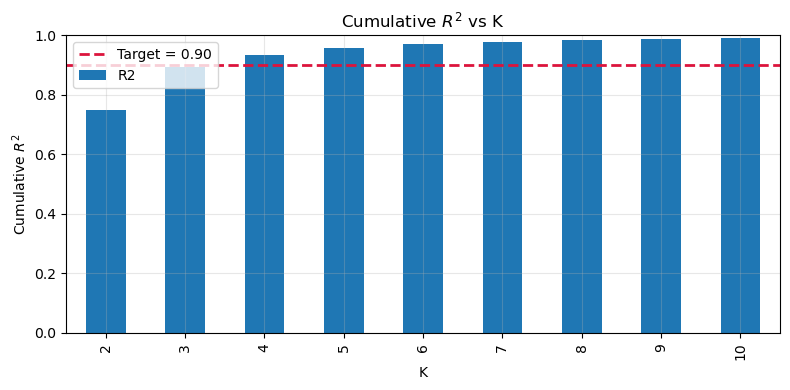

In [40]:
import matplotlib.pyplot as plt
target = 0.90

ax = results_df.plot(x="K", y="R2", kind="bar", figsize=(8,4), legend=False)
ax.axhline(target, color="crimson", linestyle="--", linewidth=2, label="Target = 0.90")

ax.set_xlabel("K")
ax.set_ylabel("Cumulative $R^2$")
ax.set_title("Cumulative $R^2$ vs K")
ax.set_ylim(0, 1.0)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Defining the rung clusters

In [41]:
from sklearn.cluster import KMeans

# number of rungs given 90% target
K = 4 

# Build rungs at neighborhood level

df2 = nyc_scores.dropna(subset=["NTACode", "score_w"]).copy()
X = df2[["score_w"]].to_numpy()
km = KMeans(n_clusters=K, n_init=50, random_state=0)
df2["cluster_raw"] = km.fit_predict(X)

# Order clusters by centroid so rung 1 is lowest-score cluster
centroids = km.cluster_centers_.ravel()           # centroid per raw cluster id
order = np.argsort(centroids)                    # raw cluster ids sorted low->high
raw_to_rung = {raw: (rank + 1) for rank, raw in enumerate(order)}

df2["rung_km"] = df2["cluster_raw"].map(raw_to_rung).astype(int)

# "Respective value": centroid score for the rung
# First map raw cluster -> centroid, then raw -> rung (or directly rung -> centroid)
raw_to_centroid = {raw: centroids[raw] for raw in range(K)}
df2["rung_value"] = df2["cluster_raw"].map(raw_to_centroid)

rungs_by_neighborhood = df2[["NTACode", "rung_km", "rung_value"]].copy()

# Merge rungs back onto original dataset
df2_out = nyc_scores.merge(rungs_by_neighborhood, on="NTACode")
df2_out.head()

C:\Users\AvaGROSSMAN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,NTACode,numer,denom,score_w,rung_km,rung_value
0,BK0101,19169.66156,38980,0.491782,3,0.476152
1,BK0102,22025.674072,53908,0.408579,2,0.422082
2,BK0103,14029.013368,37731,0.371817,1,0.367824
3,BK0104,23310.670014,52998,0.439841,2,0.422082
4,BK0201,11394.774831,25092,0.45412,3,0.476152


In [42]:
# rung-level summary
rung_summary = (df2.groupby("rung_km", as_index=False)
                  .agg(centroid=("rung_value", "mean"),
                       score_min=("score_w", "min"),
                       score_max=("score_w", "max"),
                       n_neighborhoods=("NTACode", "nunique")))
rung_summary

,rung_km,centroid,score_min,score_max,n_neighborhoods
0,1,0.367824,0.326442,0.394448,58
1,2,0.422082,0.396426,0.447085,45
2,3,0.476152,0.451417,0.509239,42
3,4,0.547024,0.512589,0.602811,52


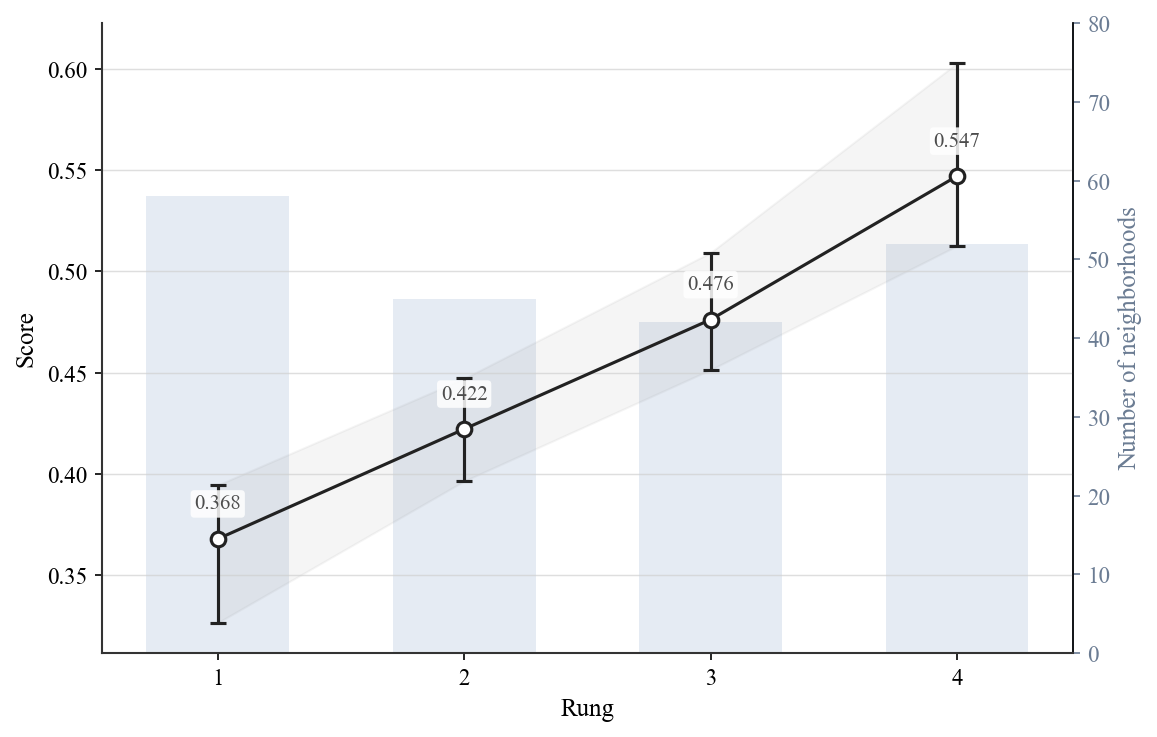

In [43]:
import matplotlib.pyplot as plt
import numpy as np

df = rung_summary.copy()

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Liberation Serif", "serif"],
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.spines.top": False,
})

x = df["rung_km"].values
y = df["centroid"].values
yerr_lower = y - df["score_min"].values
yerr_upper = df["score_max"].values - y
n = df["n_neighborhoods"].values

# Figure
fig, ax1 = plt.subplots(figsize=(7.6, 4.8), constrained_layout=True)
ax2 = ax1.twinx()

# Put the main score axis in front of the bar axis
ax1.set_zorder(3)
ax2.set_zorder(1)
ax1.patch.set_alpha(0)

bar_color = "#d7e1ee"
ax2.bar(
    x, n,
    width=0.58,
    color=bar_color,
    alpha=0.65,
    edgecolor="none",
    zorder=0
)

ax2.set_ylim(0, max(n) * 1.38)
ax2.set_ylabel("Number of neighborhoods", color="#6b7c93")
ax2.tick_params(axis="y", colors="#6b7c93")
ax2.spines["right"].set_color("#6b7c93")
ax2.spines["top"].set_visible(False)

# Min-max band
ax1.fill_between(
    x,
    df["score_min"].values,
    df["score_max"].values,
    color="gray",
    alpha=0.08,
    zorder=1
)

# Error bars and centroid line
main_color = "#222222"
ax1.errorbar(
    x, y,
    yerr=[yerr_lower, yerr_upper],
    fmt="o-",
    color=main_color,
    ecolor=main_color,
    elinewidth=1.5,
    capsize=4,
    capthick=1.2,
    markersize=7,
    linewidth=1.5,
    markerfacecolor="white",
    markeredgewidth=1.5,
    zorder=5
)

# Axis labels and ticks
ax1.set_xlabel("Rung")
ax1.set_ylabel("Score")
ax1.set_xticks(x)
ax1.set_xticklabels([str(i) for i in x])

ymin = min(df["score_min"]) - 0.015
ymax = max(df["score_max"]) + 0.02
ax1.set_ylim(ymin, ymax)

ax1.grid(axis="y", color="#d0d0d0", linewidth=0.7, alpha=0.7)
ax1.grid(axis="x", visible=False)

# Centroid labels
for xi, yi in zip(x, y):
    ax1.annotate(
        f"{yi:.3f}",
        xy=(xi, yi),
        xytext=(0, 12),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        color="#4d4d4d",
        zorder=10,
        bbox=dict(
            boxstyle="round,pad=0.18",
            facecolor="white",
            edgecolor="none",
            alpha=0.85
        ),
        clip_on=False
    )

# Spine styling
ax1.spines["left"].set_linewidth(1.0)
ax1.spines["bottom"].set_linewidth(1.0)
ax1.spines["left"].set_color("#333333")
ax1.spines["bottom"].set_color("#333333")

write_path = os.path.join(base_path, "figures", "score_by_rung_analysis.png")
fig.savefig(write_path, bbox_inches="tight")
plt.show()


### Sanity checks

In [44]:
df2_out["rung_km"].describe()

count    197.000000
mean       2.446701
std        1.170841
min        1.000000
25%        1.000000
50%        2.000000
75%        4.000000
max        4.000000
Name: rung_km, dtype: float64

In [45]:
is_duplicated_in_any_column = pd.Series([False] * len(df2_out), index=df2_out.index)

for column in ["NTACode"]:
    is_duplicated_in_any_column = is_duplicated_in_any_column | df2_out[column].duplicated(keep=False)

# Filter the DataFrame to return only the rows that are marked as True
df_duplicates_any_col = df2_out[is_duplicated_in_any_column]

print("Rows with duplicates in at least one column:")
print(df_duplicates_any_col)

Rows with duplicates in at least one column:
Empty DataFrame
Columns: [NTACode, numer, denom, score_w, rung_km, rung_value]
Index: []


## Alternate rungs approach: Defining equal width rungs

In [46]:
# --- PARAMETERS ---
K = 4  # number of rungs
score_col = "score_w"
# --- COPY DATA ---
df3 = nyc_scores.copy()

# Compute bounds
s_min = df3["score_w"].min()
s_max = df3["score_w"].max()

# Define step size 
delta = (s_max - s_min) / K

# Assign rungs
x = (df3["score_w"] - s_min) / delta
x = pd.to_numeric(x, errors="coerce").replace([np.inf, -np.inf], np.nan)

df3["rung_eq"] = np.floor(x).astype("Int64") +1  

# Cap top rung (edge case where value == s_max)
df3["rung_eq"] = df3["rung_eq"].clip(upper=K)

# Define next best rung ---
df3["next_rung"] = df3["rung_eq"] + 1
df3.loc[df3["rung_eq"] == K, "next_rung"] = np.nan

df3.head()

,NTACode,numer,denom,score_w,rung_eq,next_rung
0,BK0101,19169.66156,38980,0.491782,3,4
1,BK0102,22025.674072,53908,0.408579,2,3
2,BK0103,14029.013368,37731,0.371817,1,2
3,BK0104,23310.670014,52998,0.439841,2,3
4,BK0201,11394.774831,25092,0.45412,2,3


In [47]:
df3[df3["rung_eq"].isna()]

,NTACode,numer,denom,score_w,rung_eq,next_rung


In [48]:
df3["rung_eq"].describe()

count       197.0
mean     2.269036
std      1.056421
min           1.0
25%           1.0
50%           2.0
75%           3.0
max           4.0
Name: rung_eq, dtype: Float64

In [49]:
df3["score_w"].describe()

count       197.0
mean     0.450615
std      0.071854
min      0.326442
25%      0.386184
50%      0.440427
75%      0.513888
max      0.602811
Name: score_w, dtype: Float64

In [50]:
print(list(set(df3["NTACode"])- set(df2_out["NTACode"])))
print(list(set(df2_out["NTACode"])- set(df3["NTACode"])))
print(len(df2_out))
print(len(df3))

[]
[]
197
197


In [51]:
compare = df3.merge(df2_out[["rung_km", "NTACode"]], how="left", on="NTACode")
compare[compare['rung_eq'] != compare['rung_km']].sort_values("score_w")[["NTACode","score_w", "rung_eq","rung_km"]]

,NTACode,score_w,rung_eq,rung_km
39,BK1402,0.451417,2,3
73,BX0802,0.452344,2,3
134,QN0402,0.453172,2,3
173,QN1303,0.454068,2,3
4,BK0201,0.45412,2,3
158,QN1001,0.454193,2,3
19,BK0701,0.45741,2,3
80,BX1002,0.458357,2,3
105,MN0604,0.459658,2,3
106,MN0701,0.460125,2,3


## Visualizing against NYC neighborhood maps

In [52]:
base = (
    "https://services5.arcgis.com/GfwWNkhOj9bNBqoJ/ArcGIS/rest/services/"
    "nyc_neighborhood_tabulation_areas_2020/FeatureServer/0/query"
)

params = {
    "where": "1=1",
    "outFields": "*",
    "outSR": 4326,
    "f": "geojson",
    "orderByFields": "OBJECTID",   # important for stable paging (field name is often OBJECTID)
    "resultRecordCount": 200,
    "resultOffset": 0,
}

features = []
while True:
    r = requests.get(base, params=params, timeout=120) 
    r.raise_for_status()
    js = r.json()
    batch = js.get("features", [])
    if not batch:
        break
    features.extend(batch)
    params["resultOffset"] += len(batch)

nta_gdf = gpd.GeoDataFrame.from_features(features, crs="EPSG:4326")
nta_gdf.geometry.isna().sum(), len(nta_gdf)

(np.int64(0), 262)

In [53]:
nta_gdf.head()

,geometry,OBJECTID,BoroCode,BoroName,CountyFIPS,NTA2020,NTAName,NTAAbbrev,NTAType,CDTA2020,CDTAName,Shape__Area,Shape__Length
0,"POLYGON ((-73.93214 40.72817, -73.93238 40.728...",1,3,Brooklyn,047,BK0101,Greenpoint,Grnpt,0,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),3.532181e+07,28919.560728
1,"POLYGON ((-73.95814 40.72441, -73.95772 40.724...",2,3,Brooklyn,047,BK0102,Williamsburg,Wllmsbrg,0,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),2.885285e+07,28134.082506
2,"POLYGON ((-73.95024 40.70548, -73.94984 40.705...",3,3,Brooklyn,047,BK0103,South Williamsburg,SWllmsbrg,0,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),1.520896e+07,18250.280091
3,"POLYGON ((-73.92406 40.71412, -73.92404 40.714...",4,3,Brooklyn,047,BK0104,East Williamsburg,EWllmsbrg,0,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),5.226741e+07,43184.800375
4,"POLYGON ((-73.99237 40.6897, -73.99436 40.6902...",5,3,Brooklyn,047,BK0201,Brooklyn Heights,BkHts,0,BK02,BK02 Downtown Brooklyn-Fort Greene (CD 2 Appro...,9.982023e+06,14312.192425


In [54]:
## using kmeans labels from here on out
nta_scores = df2_out.copy() 
map_gdf = pd.DataFrame()

nta_code_poly = "NTA2020"   
nta_code_tbl  = "NTACode"        

nta_gdf[nta_code_poly] = nta_gdf[nta_code_poly].astype(str).str.strip()
nta_scores[nta_code_tbl] = nta_scores[nta_code_tbl].astype(str).str.strip()

map_gdf = nta_gdf.merge(
    nta_scores,
    left_on=nta_code_poly,
    right_on=nta_code_tbl,
    how="left"
)
map_gdf.head()

,geometry,OBJECTID,BoroCode,BoroName,CountyFIPS,NTA2020,NTAName,NTAAbbrev,NTAType,CDTA2020,CDTAName,Shape__Area,Shape__Length,NTACode,numer,denom,score_w,rung_km,rung_value
0,"POLYGON ((-73.93214 40.72817, -73.93238 40.728...",1,3,Brooklyn,047,BK0101,Greenpoint,Grnpt,0,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),3.532181e+07,28919.560728,BK0101,19169.66156,38980,0.491782,3.0,0.476152
1,"POLYGON ((-73.95814 40.72441, -73.95772 40.724...",2,3,Brooklyn,047,BK0102,Williamsburg,Wllmsbrg,0,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),2.885285e+07,28134.082506,BK0102,22025.674072,53908,0.408579,2.0,0.422082
2,"POLYGON ((-73.95024 40.70548, -73.94984 40.705...",3,3,Brooklyn,047,BK0103,South Williamsburg,SWllmsbrg,0,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),1.520896e+07,18250.280091,BK0103,14029.013368,37731,0.371817,1.0,0.367824
3,"POLYGON ((-73.92406 40.71412, -73.92404 40.714...",4,3,Brooklyn,047,BK0104,East Williamsburg,EWllmsbrg,0,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),5.226741e+07,43184.800375,BK0104,23310.670014,52998,0.439841,2.0,0.422082
4,"POLYGON ((-73.99237 40.6897, -73.99436 40.6902...",5,3,Brooklyn,047,BK0201,Brooklyn Heights,BkHts,0,BK02,BK02 Downtown Brooklyn-Fort Greene (CD 2 Appro...,9.982023e+06,14312.192425,BK0201,11394.774831,25092,0.45412,3.0,0.476152


### Sanity checks

In [55]:
map_gdf["score_w"].isna().sum(), len(map_gdf)

(np.int64(65), 262)

In [56]:
unmatched = map_gdf.loc[map_gdf["score_w"].isna(), "NTA2020"].unique()
print(len(unmatched))
#no effect as these are parks/islands/cemeteries etc
unmatched_codes = unmatched 
map_gdf.loc[
    map_gdf["NTA2020"].isin(unmatched_codes),
    ["NTA2020", "NTAName","NTAType", "BoroName"]
].sort_values(["BoroName","NTA2020"])["NTAType"].unique()

65


array(['9', '7', '6', '5', '8'], dtype=object)

In [57]:
map_gdf = map_gdf[map_gdf["NTAType"]=="0"]
map_gdf.head()

,geometry,OBJECTID,BoroCode,BoroName,CountyFIPS,NTA2020,NTAName,NTAAbbrev,NTAType,CDTA2020,CDTAName,Shape__Area,Shape__Length,NTACode,numer,denom,score_w,rung_km,rung_value
0,"POLYGON ((-73.93214 40.72817, -73.93238 40.728...",1,3,Brooklyn,047,BK0101,Greenpoint,Grnpt,0,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),3.532181e+07,28919.560728,BK0101,19169.66156,38980,0.491782,3.0,0.476152
1,"POLYGON ((-73.95814 40.72441, -73.95772 40.724...",2,3,Brooklyn,047,BK0102,Williamsburg,Wllmsbrg,0,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),2.885285e+07,28134.082506,BK0102,22025.674072,53908,0.408579,2.0,0.422082
2,"POLYGON ((-73.95024 40.70548, -73.94984 40.705...",3,3,Brooklyn,047,BK0103,South Williamsburg,SWllmsbrg,0,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),1.520896e+07,18250.280091,BK0103,14029.013368,37731,0.371817,1.0,0.367824
3,"POLYGON ((-73.92406 40.71412, -73.92404 40.714...",4,3,Brooklyn,047,BK0104,East Williamsburg,EWllmsbrg,0,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),5.226741e+07,43184.800375,BK0104,23310.670014,52998,0.439841,2.0,0.422082
4,"POLYGON ((-73.99237 40.6897, -73.99436 40.6902...",5,3,Brooklyn,047,BK0201,Brooklyn Heights,BkHts,0,BK02,BK02 Downtown Brooklyn-Fort Greene (CD 2 Appro...,9.982023e+06,14312.192425,BK0201,11394.774831,25092,0.45412,3.0,0.476152


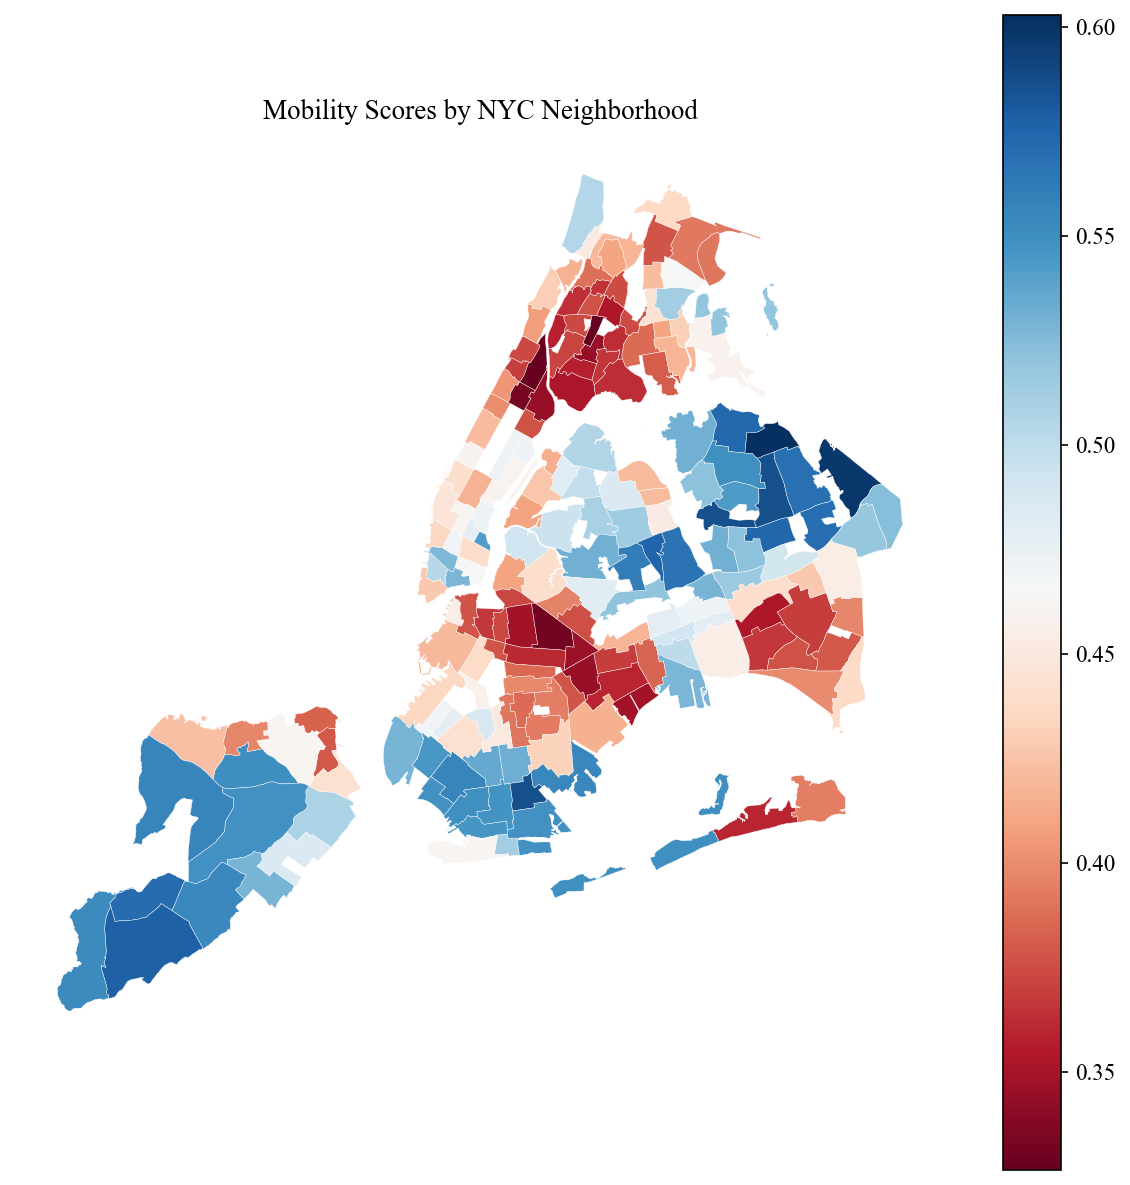

In [58]:
map_gdf["nta_score"] = pd.to_numeric(map_gdf["score_w"], errors="coerce")
ax = map_gdf.to_crs(2263).plot(
    column="nta_score",
    cmap="RdBu",
    legend=True,
    figsize=(10, 10),
    linewidth=0.2,
    edgecolor="white",
    missing_kwds={"color": "lightgrey", "label": "No data / special area"}
)
ax.set_axis_off()
ax.set_title("Mobility Scores by NYC Neighborhood")
fig = ax.get_figure()
write_path = os.path.join(base_path,"figures", "map_nta_score.png")
fig.savefig(write_path, dpi=300, bbox_inches="tight", pad_inches=.5)


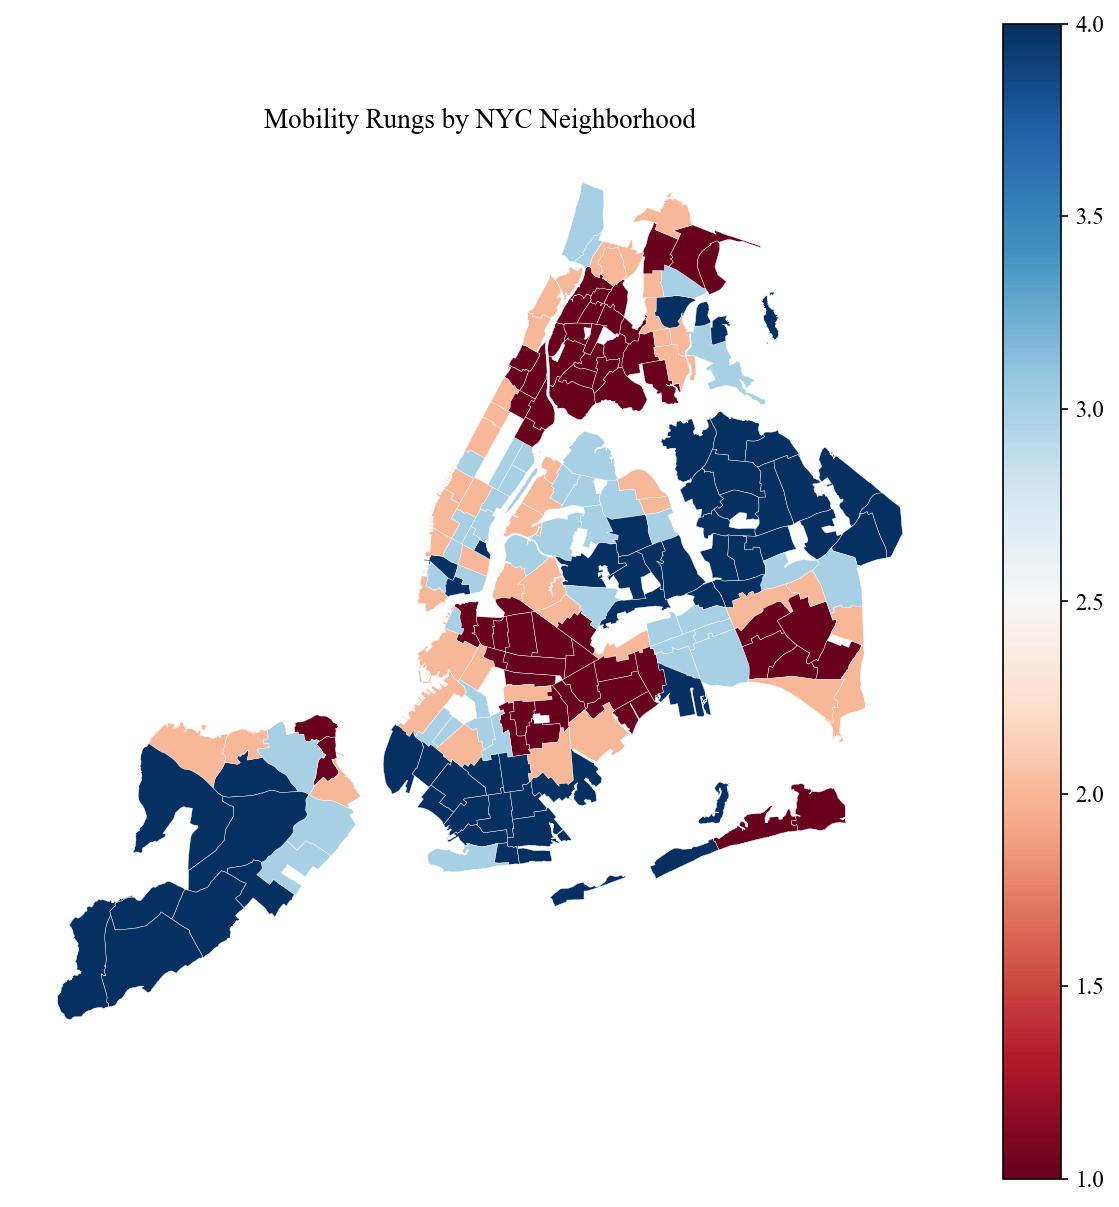

In [59]:
ax = map_gdf.to_crs(2263).plot(
    column="rung_km",
    cmap="RdBu",
    legend=True,
    figsize=(10, 10),
    linewidth=0.2,
    edgecolor="white",
    missing_kwds={"color": "lightgrey", "label": "No data / special area"}
)
ax.set_axis_off()
ax.set_title("Mobility Rungs by NYC Neighborhood")
fig = ax.get_figure()

write_path = os.path.join(base_path,"figures", "map_km_rung.png")
fig.savefig(write_path, dpi=300, bbox_inches="tight", pad_inches=.5)


## Overlaying the MTA Subway Stations

In [60]:
import requests
url = "http://web.mta.info/developers/data/nyct/subway/google_transit.zip" 
out  = os.path.join(base_path,"data_raw", "google_transit.zip")

with requests.get(url, stream=True, timeout=120) as r:
    r.raise_for_status()
    with open(out, "wb") as f:
        for chunk in r.iter_content(chunk_size=1024*1024):
            if chunk:
                f.write(chunk)

In [61]:
gtfs_zip = os.path.join(base_path,"data_raw", "google_transit.zip")

with zipfile.ZipFile(gtfs_zip) as z:
    stops = pd.read_csv(z.open("stops.txt"), dtype=str)
    stop_times = pd.read_csv(z.open("stop_times.txt"), dtype=str)
    trips = pd.read_csv(z.open("trips.txt"), dtype=str)

stops["stop_lat"] = stops["stop_lat"].astype(float)
stops["stop_lon"] = stops["stop_lon"].astype(float)

stops_gdf = gpd.GeoDataFrame(
    stops,
    geometry=gpd.points_from_xy(stops["stop_lon"], stops["stop_lat"]),
    crs="EPSG:4326"
).to_crs(2263)

In [62]:
nta_plot = map_gdf.to_crs(2263)
stops_plot = stops_gdf.to_crs(2263)

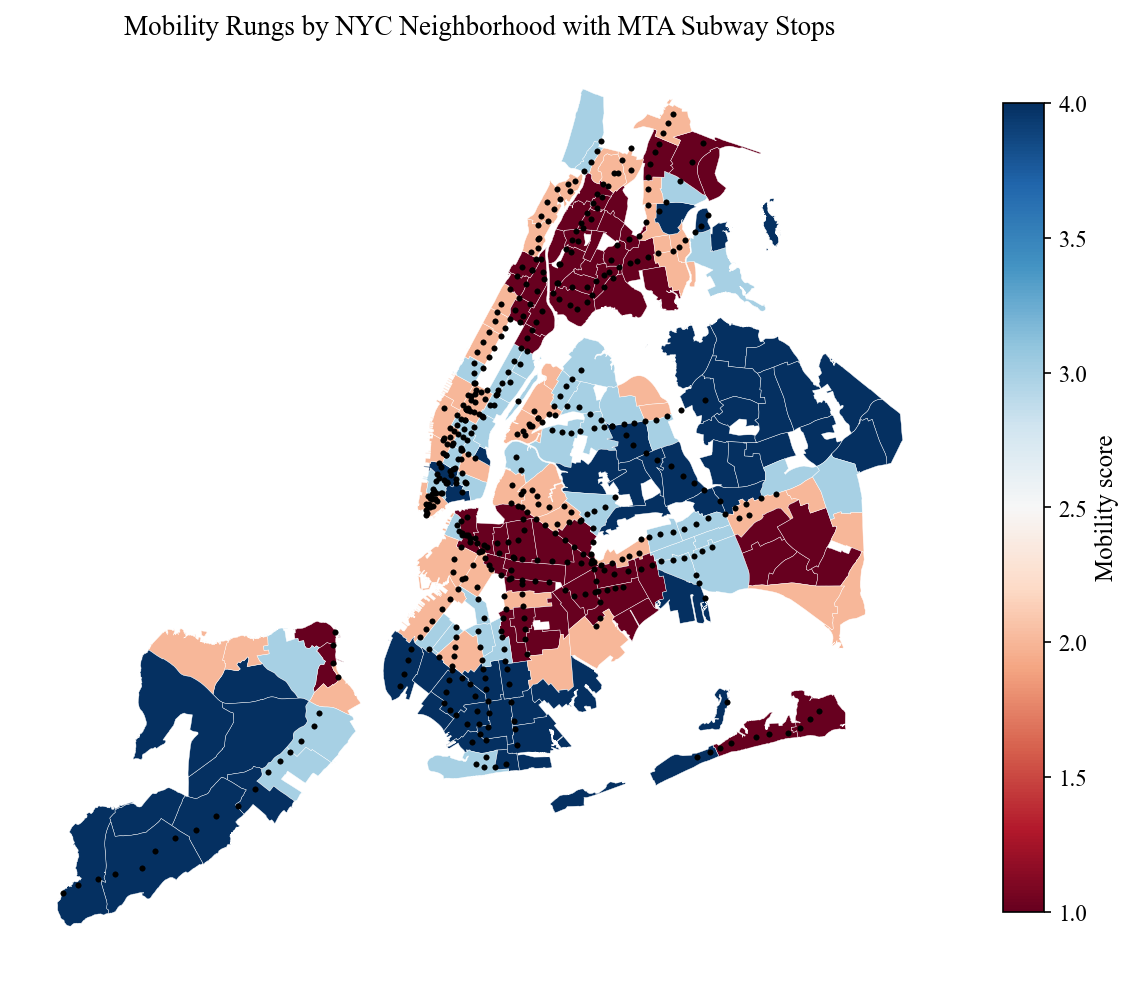

In [63]:
ax = nta_plot.plot(
    column="rung_km",
    cmap="RdBu",
    legend=True,
    figsize=(10, 10),
    linewidth=0.2,
    edgecolor="white",
    missing_kwds={"color": "lightgrey", "label": "No data / special area"},
    legend_kwds={"label": "Mobility score", "shrink": 0.7}
)

stops_plot.plot(
    ax=ax,
    color="black",
    markersize=3,   # adjust size
    alpha=0.7
)

ax.set_axis_off()
ax.set_title("Mobility Rungs by NYC Neighborhood with MTA Subway Stops")
fig = ax.get_figure()
fig.savefig(os.path.join(base_path,"figures", "map_km_rung_w_mta.png"), dpi=300, bbox_inches="tight", pad_inches=.5)

## Approximating time to get from each origin to destination

In [64]:
nta_pts = nta_gdf.to_crs(2263).copy()
nta_pts["pt"] = nta_pts.geometry.representative_point()
nta_pts = nta_pts.set_geometry("pt") 
stops_2263 = stops_gdf.to_crs(2263).copy()

In [65]:
print("nta:", nta_pts.crs)
print("stops:", stops_2263.crs)

nta: EPSG:2263
stops: EPSG:2263


In [66]:
# --- constants ---
K = 5
WALK_MPS = 1.4  # walking speed (meters / second)

# EPSG:2263 distances are in US survey feet
US_SURVEY_FT_TO_M = 0.3048006096

def nearest_k_stops(point, k=K):
    # distances in US survey feet (because CRS is EPSG:2263)
    d_ft = stops_2263.distance(point)
    ix = d_ft.nsmallest(k).index
    out = stops_2263.loc[ix, ["stop_id"]].copy()
    # convert feet -> meters -> seconds at WALK_MPS
    out["walk_sec"] = (d_ft.loc[ix].to_numpy() * US_SURVEY_FT_TO_M) / WALK_MPS
    return out

# build NTA -> nearest stops table 
rows = []
for _, r in nta_pts[["NTA2020", "pt"]].iterrows():
    tmp = nearest_k_stops(r["pt"], k=K)
    tmp["NTA2020"] = r["NTA2020"]
    rows.append(tmp)

nta_access = pd.concat(rows, ignore_index=True)[["NTA2020", "stop_id", "walk_sec"]]

#  dictionary for fast lookup later 
access_by_nta = {
    nta: grp[["stop_id", "walk_sec"]].to_records(index=False)
    for nta, grp in nta_access.groupby("NTA2020")
}

In [67]:
# Parse GTFS times
def hhmmss_to_seconds(x):
    if x is None or pd.isna(x):
        return pd.NA
    x = str(x).strip()
    if not x:
        return pd.NA

    parts = x.split(":")
    if len(parts) != 3:
        return pd.NA

    try:
        h, m, s = (int(parts[0]), int(parts[1]), int(parts[2]))
    except ValueError:
        return pd.NA

    return h * 3600 + m * 60 + s


# Compute travel time between consecutive stops

# Keep only stop_times for trips we care about
trip_ids = trips["trip_id"].dropna().unique()
st = stop_times.loc[stop_times["trip_id"].isin(trip_ids)].copy()

# Ensure numeric stop order
st["stop_sequence"] = pd.to_numeric(st["stop_sequence"], errors="coerce").astype("Int64")
st = st.dropna(subset=["stop_sequence"])

# Prefer departure_time; fall back to arrival_time if departure is missing
time_str = st["departure_time"].fillna(st.get("arrival_time"))
st = st.assign(t=time_str.map(hhmmss_to_seconds))
st = st.dropna(subset=["t"])

# Sort within each trip
st = st.sort_values(["trip_id", "stop_sequence"])

# Consecutive stop pairs within each trip
st["v"] = st.groupby("trip_id")["stop_id"].shift(-1)
st["t_next"] = st.groupby("trip_id")["t"].shift(-1)

pairs = st.dropna(subset=["v", "t_next"]).copy()
pairs = pairs.rename(columns={"stop_id": "u"})
pairs["dt"] = pairs["t_next"] - pairs["t"]

# Keep only sane, positive travel times (drop zero/negative and bad rows)
pairs = pairs[pairs["dt"].notna() & (pairs["dt"] > 0)]

# Typical time per directed edge (u -> v)
edge_times = (
    pairs.groupby(["u", "v"], as_index=False)["dt"]
         .median()
         .rename(columns={"dt": "sec"})
)

edge_times

,u,v,sec
0,101S,103S,90.0
1,103N,101N,90.0
2,103S,104S,90.0
3,104N,103N,210.0
4,104S,106S,90.0
...,...,...,...
1143,S29S,S28S,120.0
1144,S30N,S31N,180.0
1145,S30S,S29S,120.0
1146,S31S,S19S,960.0


In [68]:
# Create the NetworkX graph
G = nx.DiGraph()

stops_df = stops_plot  

# Ensure consistent stop_id types
stops_df = stops_df.copy()
stops_df["stop_id"] = stops_df["stop_id"].astype(str)

# Build an explicit 'edges' table from edge_times
edges = edge_times.copy()
edges["u"] = edges["u"].astype(str)
edges["v"] = edges["v"].astype(str)
edges["sec"] = pd.to_numeric(edges["sec"], errors="coerce")

# Add nodes
G.add_nodes_from(stops_df["stop_id"].tolist())

# Add directed edges with travel times (seconds)
for u, v, sec in edges[["u", "v", "sec"]].itertuples(index=False, name=None):
    if pd.notna(sec) and sec > 0:
        w = float(sec)
        # don't overwrite an existing smaller weight
        if G.has_edge(u, v):
            G[u][v]["weight"] = min(G[u][v]["weight"], w)
        else:
            G.add_edge(u, v, weight=w)

# Add transfers (necessary for connectivity) 
TRANSFER_SEC = 120.0

if "parent_station" in stops_df.columns:
    ps = stops_df.dropna(subset=["parent_station"])[["stop_id", "parent_station"]].copy()
    ps["parent_station"] = ps["parent_station"].astype(str)

    for _, grp in ps.groupby("parent_station"):
        ids = grp["stop_id"].tolist()
        n = len(ids)
        for i in range(n):
            a = ids[i]
            for j in range(i + 1, n):
                b = ids[j]
                for x, y in ((a, b), (b, a)):
                    if G.has_edge(x, y):
                        G[x][y]["weight"] = min(G[x][y]["weight"], TRANSFER_SEC)
                    else:
                        G.add_edge(x, y, weight=TRANSFER_SEC)


In [69]:
SRC = "__SRC__"
if SRC not in G:
    G.add_node(SRC)

# all NTAs that have access stops
nta_list = list(access_by_nta.keys())

travel_rows = []

for origin in nta_list:
    # clear any previous iteration's SRC outgoing edges
    G.remove_edges_from(list(G.out_edges(SRC)))

    # add walking edges: SRC -> origin access stops (walk-in)
    for stop_id, walk_in_sec in access_by_nta[origin]:
        sid = str(stop_id)  # keep consistent with graph node ids
        if sid in G:
            G.add_edge(SRC, sid, weight=float(walk_in_sec))

    # shortest path from SRC to all reachable stops
    dist = nx.single_source_dijkstra_path_length(G, SRC, weight="weight")

    # evaluate every destination NTA: min_{dest access stop} dist(stop) + walk-out
    for dest in nta_list:
        best = np.inf
        for stop_id, walk_out_sec in access_by_nta[dest]:
            sid = str(stop_id)
            if sid in dist:
                cand = dist[sid] + float(walk_out_sec)
                if cand < best:
                    best = cand

        if np.isfinite(best):
            travel_rows.append({"origin": origin, "dest": dest, "travel_sec": best})

travel_costs = pd.DataFrame(travel_rows)

In [70]:
# quick check
print("travel_costs shape:", travel_costs.shape)
print("travel_costs columns:", travel_costs.columns.tolist())

travel_costs shape: (31422, 3)
travel_costs columns: ['origin', 'dest', 'travel_sec']


In [71]:
# Merge (origin NTA, dest NTA) pairs with the computed transit travel times

od_pairs = edges.copy()

# enforce naming conventions used above
rename_map = {
    "u": "origin",
    "v": "dest",
    "from": "origin",
    "to": "dest",
    "NTA2020_origin": "origin",
    "NTA2020_dest": "dest",
}
od_pairs = od_pairs.rename(columns={k: v for k, v in rename_map.items() if k in od_pairs.columns})

# keep only required columns
od_pairs = od_pairs[["origin", "dest"]].drop_duplicates()

edges_subway = od_pairs.merge(travel_costs, on=["origin", "dest"], how="left")

# --- best destination (minimum travel time) per origin ---
if travel_costs.empty:
    best_by_time = pd.DataFrame(columns=["origin", "dest", "travel_sec"])
else:
    best_by_time = (
        travel_costs
        .dropna(subset=["travel_sec"])
        .query("origin != dest")
        .loc[lambda df: df.groupby("origin")["travel_sec"].idxmin()]
        .reset_index(drop=True)
    )

In [72]:
travel_costs.loc[travel_costs["origin"] == travel_costs["dest"], "travel_sec"] = 0.0
travel_costs["travel_min"]=travel_costs["travel_sec"]/60
travel_costs = travel_costs[travel_costs["travel_sec"]!=0]

## Merging rungs to travel time to rank by score and time

In [73]:
tc = travel_costs.copy()
tc["origin"] = tc["origin"].astype(str).str.strip()
tc["dest"]   = tc["dest"].astype(str).str.strip()

# Build a unique NTA -> rung table
NTA_COL = "NTACode"
RUNG_COL = "rung_km"

nta_rungs = df2_out[[NTA_COL, RUNG_COL]].copy()
nta_rungs[NTA_COL] = nta_rungs[NTA_COL].astype(str).str.strip()
nta_rungs[RUNG_COL] = pd.to_numeric(nta_rungs[RUNG_COL], errors="coerce")

# ensure one row per NTA (required for m:1 validation)
nta_rungs = nta_rungs.drop_duplicates(subset=[NTA_COL]).rename(columns={NTA_COL: "nta", RUNG_COL: "rung"})

#  Merge rungs onto travel_costs
travel_with_rungs = (
    tc.merge(nta_rungs.rename(columns={"nta": "origin", "rung": "origin_rung"}),
             on="origin", how="left", validate="m:1")
      .merge(nta_rungs.rename(columns={"nta": "dest", "rung": "dest_rung"}),
             on="dest", how="left", validate="m:1")
)

### Sanity checks

In [74]:
print("travel_costs rows:", len(tc))
print("travel_with_rungs rows:", len(travel_with_rungs))
print("missing origin_rung:", travel_with_rungs["origin_rung"].isna().sum())
print("missing dest_rung:", travel_with_rungs["dest_rung"].isna().sum())

travel_costs rows: 31160
travel_with_rungs rows: 31160
missing origin_rung: 7127
missing dest_rung: 7127


### All data

In [75]:
#  filter to "next rung" and compute best destination per origin ---
cand = travel_with_rungs.dropna(subset=["travel_sec", "origin_rung", "dest_rung"]).copy()
cand = cand[cand["origin"] != cand["dest"]]

cand["origin_rung"] = cand["origin_rung"].astype(int)
cand["dest_rung"]   = cand["dest_rung"].astype(int)
cand.head()

,origin,dest,travel_sec,travel_min,origin_rung,dest_rung
0,BK0101,BK0102,1227.220331,20.453672,3,2
1,BK0101,BK0103,3404.063508,56.734392,3,1
2,BK0101,BK0201,3343.307849,55.721797,3,3
3,BK0101,BK0202,1684.360741,28.072679,3,1
4,BK0101,BK0203,1435.602285,23.926705,3,1


In [76]:
cand = cand.sort_values(["origin", "travel_sec"], ascending=[True, True]).copy()
cand["all_dest_time_rank"] = cand.groupby("origin").cumcount() + 1   # this is just an order rank

In [77]:
#get neighborhood scores
SCORE_COL = "score_w"
NTA_COL = "NTACode"

nta_lu = (
    df2_out[[NTA_COL, SCORE_COL]]
    .copy()
    .drop_duplicates(subset=[NTA_COL])
    .rename(columns={
        NTA_COL: "nta",
        SCORE_COL: "score",
    })
)

# Clean join keys
nta_lu["nta"] = nta_lu["nta"].astype(str).str.strip()

out = cand.copy()
out["origin"] = out["origin"].astype(str).str.strip()
out["dest"]   = out["dest"].astype(str).str.strip()

# Merge origin attributes
out = out.merge(
    nta_lu.rename(columns={
        "nta": "origin",
        "nta_name": "origin_name",
        "score": "origin_score",
    }),
    on="origin",
    how="left",
    validate="m:1",
)

# Merge destination attributes
out = out.merge(
    nta_lu.rename(columns={
        "nta": "dest",
        "nta_name": "dest_name",
        "rung": "dest_rung",
        "score": "dest_score",
    }),
    on="dest",
    how="left",
    validate="m:1",
)

print(len(out) == len(cand))

True


In [78]:
#get neighborhood names
NTA_NAME = "NTAName"
NTA_COL = "NTACode"

nta_lu = (
    eq[[NTA_COL, NTA_NAME]]
    .copy()
    .drop_duplicates(subset=[NTA_COL])
    .rename(columns={
        NTA_COL: "nta",
        NTA_NAME: "nta_name",
    })
)

# Clean join keys
nta_lu["nta"] = nta_lu["nta"].astype(str).str.strip()

out["origin"] = out["origin"].astype(str).str.strip()
out["dest"]   = out["dest"].astype(str).str.strip()

# Merge origin attributes
out = out.merge(
    nta_lu.rename(columns={
        "nta": "origin",
        "nta_name": "origin_name",
    }),
    on="origin",
    how="left",
    validate="m:1")

# Merge destination attributes
out = out.merge(
    nta_lu.rename(columns={
        "nta": "dest",
        "nta_name": "dest_name",

    }),
    on="dest",
    how="left",
    validate="m:1"
)

print(len(out) == len(cand))

True


In [79]:
cand = out.copy()
cand.head()

,origin,dest,travel_sec,travel_min,origin_rung,dest_rung,all_dest_time_rank,origin_score,dest_score,origin_name,dest_name
0,BK0101,QN0201,769.586391,12.826440,3,2,1,0.491782,0.408501,Greenpoint,Long Island City-Hunters Point
1,BK0101,BK0301,1065.437898,17.757298,3,1,2,0.491782,0.34805,Greenpoint,Bedford-Stuyvesant (West)
2,BK0101,BK0204,1212.192661,20.203211,3,1,3,0.491782,0.37345,Greenpoint,Clinton Hill
3,BK0101,BK0102,1227.220331,20.453672,3,2,4,0.491782,0.408579,Greenpoint,Williamsburg
4,BK0101,BK0203,1435.602285,23.926705,3,1,5,0.491782,0.366761,Greenpoint,Fort Greene


In [80]:
#differences in score
cand = cand[cand["origin"] != cand["dest"]]
cand["delta_rung"] = cand["dest_rung"] - cand["origin_rung"]
cand["score_diff"] = cand["dest_score"] - cand["origin_score"]
cand["min_travel_flag"] = (cand["travel_min"]==cand.groupby("origin")["travel_min"].transform("min")).astype(int)
cand.head()

,origin,dest,travel_sec,travel_min,origin_rung,dest_rung,all_dest_time_rank,origin_score,dest_score,origin_name,dest_name,delta_rung,score_diff,min_travel_flag
0,BK0101,QN0201,769.586391,12.826440,3,2,1,0.491782,0.408501,Greenpoint,Long Island City-Hunters Point,-1,-0.083281,1
1,BK0101,BK0301,1065.437898,17.757298,3,1,2,0.491782,0.34805,Greenpoint,Bedford-Stuyvesant (West),-2,-0.143732,0
2,BK0101,BK0204,1212.192661,20.203211,3,1,3,0.491782,0.37345,Greenpoint,Clinton Hill,-2,-0.118332,0
3,BK0101,BK0102,1227.220331,20.453672,3,2,4,0.491782,0.408579,Greenpoint,Williamsburg,-1,-0.083203,0
4,BK0101,BK0203,1435.602285,23.926705,3,1,5,0.491782,0.366761,Greenpoint,Fort Greene,-2,-0.125021,0


In [81]:
#where dest rung =+1 from origin, show gain
cand["dest_pos_delta_rung_flag"] = np.where(
    cand["dest_rung"] > cand["origin_rung"],
    1, 0
)

mask = cand["dest_pos_delta_rung_flag"].eq(1)

cand["abs_gain"] = np.nan
cand.loc[mask, "abs_gain"] = cand.loc[mask, "dest_score"] - cand.loc[mask, "origin_score"]

cand.head()

,origin,dest,travel_sec,travel_min,origin_rung,dest_rung,all_dest_time_rank,origin_score,dest_score,origin_name,dest_name,delta_rung,score_diff,min_travel_flag,dest_pos_delta_rung_flag,abs_gain
0,BK0101,QN0201,769.586391,12.826440,3,2,1,0.491782,0.408501,Greenpoint,Long Island City-Hunters Point,-1,-0.083281,1,0,NaN
1,BK0101,BK0301,1065.437898,17.757298,3,1,2,0.491782,0.34805,Greenpoint,Bedford-Stuyvesant (West),-2,-0.143732,0,0,NaN
2,BK0101,BK0204,1212.192661,20.203211,3,1,3,0.491782,0.37345,Greenpoint,Clinton Hill,-2,-0.118332,0,0,NaN
3,BK0101,BK0102,1227.220331,20.453672,3,2,4,0.491782,0.408579,Greenpoint,Williamsburg,-1,-0.083203,0,0,NaN
4,BK0101,BK0203,1435.602285,23.926705,3,1,5,0.491782,0.366761,Greenpoint,Fort Greene,-2,-0.125021,0,0,NaN


In [82]:
#use time to get efficiency
cand["score_time_efficiency"] = np.nan
cand.loc[mask, "score_time_efficiency"] = cand.loc[mask, "abs_gain"]  / cand.loc[mask, "travel_min"]
cand.head()

cand["score_time_eff_rank"] = np.nan

cand.loc[mask, "score_time_eff_rank"] = (
    cand.loc[mask]
    .groupby("origin")["score_time_efficiency"]
    .rank(method="first", ascending=False)
    .astype(int)
)
cand[cand["score_time_eff_rank"].notna()].sort_values(["origin","score_time_eff_rank"])

,origin,dest,travel_sec,travel_min,origin_rung,dest_rung,all_dest_time_rank,origin_score,dest_score,origin_name,dest_name,delta_rung,score_diff,min_travel_flag,dest_pos_delta_rung_flag,abs_gain,score_time_efficiency,score_time_eff_rank
74,BK0101,BK1502,4468.110731,74.468512,3,4,75,0.491782,0.586059,Greenpoint,Madison,1,0.094277,0,1,0.094277,0.001266,1.0
68,BK0101,QN0601,4306.106309,71.768438,3,4,69,0.491782,0.574927,Greenpoint,Rego Park,1,0.083145,0,1,0.083145,0.001159,2.0
7,BK0101,MN0301,1899.809799,31.663497,3,4,8,0.491782,0.528278,Greenpoint,Chinatown-Two Bridges,1,0.036496,0,1,0.036496,0.001153,3.0
54,BK0101,QN0602,3972.501033,66.208351,3,4,55,0.491782,0.566192,Greenpoint,Forest Hills,1,0.07441,0,1,0.074410,0.001124,4.0
18,BK0101,BK1204,2596.615081,43.276918,3,4,19,0.491782,0.535229,Greenpoint,Mapleton-Midwood (West),1,0.043447,0,1,0.043447,0.001004,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18369,SI0202,SI0203,1346.182617,22.436377,3,4,4,0.48547,0.548753,New Dorp-Midland Beach,Todt Hill-Emerson Hill-Lighthouse Hill-Manor H...,1,0.063283,0,1,0.063283,0.002821,4.0
18375,SI0202,SI0303,2378.771880,39.646198,3,4,10,0.48547,0.571453,New Dorp-Midland Beach,Arden Heights-Rossville,1,0.085983,0,1,0.085983,0.002169,5.0
18374,SI0202,SI0305,1974.347181,32.905786,3,4,9,0.48547,0.552179,New Dorp-Midland Beach,Tottenville-Charleston,1,0.066709,0,1,0.066709,0.002027,6.0
18377,SI0202,SI0204,3554.647020,59.244117,3,4,12,0.48547,0.555999,New Dorp-Midland Beach,New Springville-Willowbrook-Bulls Head-Travis,1,0.070529,0,1,0.070529,0.001190,7.0


In [83]:
cand = cand[['origin',"origin_name","origin_score", 'dest', "dest_name","dest_score",'score_diff', 'abs_gain', 'travel_sec', 'travel_min','all_dest_time_rank', 'min_travel_flag', 'origin_rung',
       'dest_rung',  'delta_rung',  'dest_pos_delta_rung_flag', 'score_time_efficiency','score_time_eff_rank']]
cand.head()

,origin,origin_name,origin_score,dest,dest_name,dest_score,score_diff,abs_gain,travel_sec,travel_min,all_dest_time_rank,min_travel_flag,origin_rung,dest_rung,delta_rung,dest_pos_delta_rung_flag,score_time_efficiency,score_time_eff_rank
0,BK0101,Greenpoint,0.491782,QN0201,Long Island City-Hunters Point,0.408501,-0.083281,NaN,769.586391,12.826440,1,1,3,2,-1,0,NaN,NaN
1,BK0101,Greenpoint,0.491782,BK0301,Bedford-Stuyvesant (West),0.34805,-0.143732,NaN,1065.437898,17.757298,2,0,3,1,-2,0,NaN,NaN
2,BK0101,Greenpoint,0.491782,BK0204,Clinton Hill,0.37345,-0.118332,NaN,1212.192661,20.203211,3,0,3,1,-2,0,NaN,NaN
3,BK0101,Greenpoint,0.491782,BK0102,Williamsburg,0.408579,-0.083203,NaN,1227.220331,20.453672,4,0,3,2,-1,0,NaN,NaN
4,BK0101,Greenpoint,0.491782,BK0203,Fort Greene,0.366761,-0.125021,NaN,1435.602285,23.926705,5,0,3,1,-2,0,NaN,NaN


In [86]:
cand.to_csv(os.path.join(base_path, "data_raw","results","all_analysis.csv"),index=False)
cand[cand["delta_rung"]>=1].to_csv(os.path.join(base_path, "data_raw","results","all_analysis_delta_pos.csv"),index=False)